<a href="https://colab.research.google.com/github/ahmedgomaa512/DEBI_Ahmed_Gomaa/blob/main/Task_nn(numbers).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

### 1 - Loading Data

In [28]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

### 2 - Understanding Data

In [29]:
print (f"Shape of x_train : {x_train.shape}")
print (f"Shape of y_train : {y_train.shape}")
print (f"Shape of x_test : {x_test.shape}")
print (f"Shape of y_test : {y_test.shape}")

Shape of x_train : (60000, 28, 28)
Shape of y_train : (60000,)
Shape of x_test : (10000, 28, 28)
Shape of y_test : (10000,)


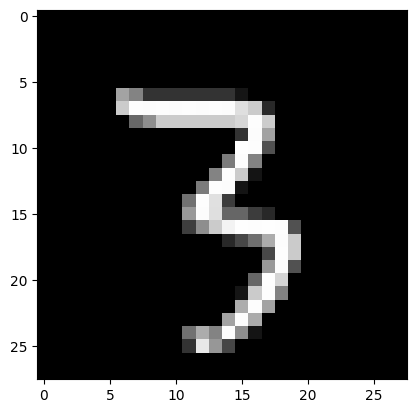

In [30]:
# Visualize one image
imgshow = plt.imshow(x_train[44], cmap = "gray")
imgshow

In [31]:
#Understand labels
np.unique (y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

### 3 - Flatten Data and Normalize it

In [32]:
#Flatten data and normalize it
x_train = x_train.reshape (x_train.shape [0],-1) / 255.0
x_test = x_test.reshape (x_test.shape [0],-1) / 255.0

In [38]:
# Note : In the mathmatical structure of NN x_train will be input as (784,60000) but in Keras and TF it input as (60000,784)
print (f"The shape of flattened and normalized x_train : {x_train.shape}")
print (f"The shape of flattened and normalized x_test : {x_test.shape}")

The shape of flattened and normalized x_train : (60000, 784)
The shape of flattened and normalized x_test : (10000, 784)


### 4 - One hot Encoding labels

In [40]:
y_train = to_categorical (y_train)
y_test = to_categorical (y_test)

In [43]:
print (f"The shape of one hot encoded y_train : {y_train.shape}")
print (f"The shape of one hot encoded y_test : {y_test.shape}")

The shape of one hot encoded y_train : (60000, 10)
The shape of one hot encoded y_test : (10000, 10)


### 5 - Bulding NN Model

In [45]:
model = keras.Sequential([
    keras.Input (shape = (784,)),
    layers.Dense (128,activation = 'relu'),
    layers.Dense (64,activation = 'relu'),
    layers.Dense (10, activation= 'softmax')

])

### 6 - Complie NN Model

In [46]:
model.compile (
    optimizer = 'Adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

### 7 - Train NN Model

In [47]:
model.fit (x_train,y_train,epochs = 10, batch_size = 32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8783 - loss: 0.4212
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9686 - loss: 0.1027
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9787 - loss: 0.0695
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9854 - loss: 0.0469
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9876 - loss: 0.0385
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9900 - loss: 0.0308
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9920 - loss: 0.0259
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9926 - loss: 0.0211
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9947 - loss: 0.0173
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9934 - loss: 0.0193


### 8 - NN Model Evaluation

In [49]:
test_loss , test_acc = model.evaluate (x_test,y_test)
print (f"Test Accuracy = {test_acc*100} %")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9712 - loss: 0.1246
Test Accuracy = 97.53999710083008 %


### 9 - NN Model Prediction

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predition of 40th example is 1


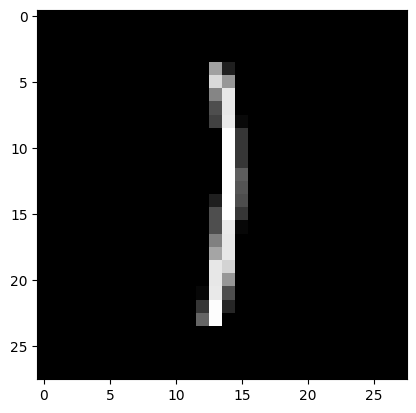

In [58]:
y_pred = model.predict (x_test)
print (f"Predition of {40}th example is {np.argmax(y_pred[40])}")
imgshow = plt.imshow(x_test[40].reshape(28,28), cmap = "gray")
imgshow

In [59]:
x = 6